<h1><b>Classification Task</b></h1>

**Student Name:** Ugesh Dhungel
**Student ID:** 2513636
**Module:** 5CS037 - Concepts and Technologies of AI
**Dataset:** Cardiovascular Disease dataset

<h1>TASK 1: EDA &amp; DATA UNDERSTANDING</h1>

# Library Imports

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


<h2>Load the dataset into a pandas DataFrame</h2>

In [150]:
df = pd.read_csv('cardio_train.csv', sep=';')

# Quick preview
df.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0.0,18393.0,2.0,168.0,52.0,85.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.0,20228.0,1.0,156.0,100.0,175.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0
2,2.0,18857.0,1.0,165.0,79.0,165.0,70.0,3.0,1.0,0.0,0.0,0.0,1.0
3,3.0,17623.0,2.0,169.0,97.0,185.0,100.0,3.0,1.0,0.0,0.0,1.0,1.0
4,4.0,17474.0,1.0,156.0,46.0,75.0,60.0,1.0,1.0,0.0,0.0,0.0,0.0


<h2>Dataset Quality Assessment</h2>

In [151]:
print("Shape:", df.shape)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Target class distribution:")
print(df['cardio'].value_counts())
print()
print("Target class proportions (%):")
print((df['cardio'].value_counts(normalize=True) * 100).round(2))


Shape: (70000, 13)

Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0

Target class distribution:
cardio
0.0    35021
1.0    34979
Name: count, dtype: int64

Target class proportions (%):
cardio
0.0    50.03
1.0    49.97
Name: proportion, dtype: float64


**Observation:** There are no missing values in any column. There are, however, some duplicate rows and physically implausible values in the blood-pressure columns (e.g. negative or zero readings, diastolic pressure higher than systolic), which are addressed in the data-cleaning section below. The target variable `cardio` is almost perfectly balanced (~50/50), so class imbalance is not expected to be a major concern for this dataset.

<h2>DATA PREPROCESSING</h2>

<h3>Remove invalid rows</h3>

We check for physically impossible or highly unlikely medical records (e.g., negative blood pressures, diastolic higher than systolic, extreme outliers).

In [152]:
before = len(df)
# Clean blood pressure outliers and impossible values
df = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <= 250) &
        (df['ap_lo'] >= 40) & (df['ap_lo'] <= 200) &
        (df['ap_lo'] <= df['ap_hi'])].copy()

# Ensure physical metrics are positive
df = df[(df['height'] > 100) & (df['weight'] > 30)].copy()

print(f"Rows removed as invalid: {before - len(df)}")
print(f"Remaining rows: {len(df)}")


Rows removed as invalid: 2006
Remaining rows: 67994


<h3>Convert Age to Years</h3>

In [153]:
# Convert age in days to age in years
df['age_years'] = (df['age'] / 365.25).round().astype(int)
df = df.drop(columns=['age'])
df.head()


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0.0,2.0,168.0,52.0,85.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,50
1,1.0,1.0,156.0,100.0,175.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,55
2,2.0,1.0,165.0,79.0,165.0,70.0,3.0,1.0,0.0,0.0,0.0,1.0,52
3,3.0,2.0,169.0,97.0,185.0,100.0,3.0,1.0,0.0,0.0,1.0,1.0,48
4,4.0,1.0,156.0,46.0,75.0,60.0,1.0,1.0,0.0,0.0,0.0,0.0,48


<h3>Remove Duplicate Rows</h3>

In [154]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicate rows removed: {before - len(df)}")
print(f"Remaining rows: {len(df)}")


Duplicate rows removed: 0
Remaining rows: 67994


<h3>Drop Identifier Columns</h3>

The `id` column is just a row identifier and carries no predictive value, so it is dropped.

In [155]:
df = df.drop(columns=['id'], errors='ignore')
df.head()


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2.0,168.0,52.0,85.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,50
1,1.0,156.0,100.0,175.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,55
2,1.0,165.0,79.0,165.0,70.0,3.0,1.0,0.0,0.0,0.0,1.0,52
3,2.0,169.0,97.0,185.0,100.0,3.0,1.0,0.0,0.0,1.0,1.0,48
4,1.0,156.0,46.0,75.0,60.0,1.0,1.0,0.0,0.0,0.0,0.0,48


<h3>Identify Feature Types</h3>

In [156]:
numeric_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']
Categorical: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


<h3>Feature Engineering: Body Mass Index (BMI)</h3>

In [157]:
# BMI is a well-known clinical indicator not directly present in the raw data,
# so we derive it from height and weight.
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
numeric_features.append('bmi')
df.head()


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,2.0,168.0,52.0,85.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,50,18.424036
1,1.0,156.0,100.0,175.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,55,41.091387
2,1.0,165.0,79.0,165.0,70.0,3.0,1.0,0.0,0.0,0.0,1.0,52,29.017447
3,2.0,169.0,97.0,185.0,100.0,3.0,1.0,0.0,0.0,1.0,1.0,48,33.962396
4,1.0,156.0,46.0,75.0,60.0,1.0,1.0,0.0,0.0,0.0,0.0,48,18.902038


<h3>Feature Engineering: Pulse Pressure and Age-Cholesterol Interaction</h3>


In [158]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['age_chol_interaction'] = df['age_years'] * df['cholesterol']

numeric_features.append('pulse_pressure')
numeric_features.append('age_chol_interaction')

print("Updated numeric features:", numeric_features)
df.head()


Updated numeric features: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'age_chol_interaction']


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,age_chol_interaction
0,2.0,168.0,52.0,85.0,80.0,1.0,1.0,0.0,0.0,1.0,0.0,50,18.424036,5.0,50.0
1,1.0,156.0,100.0,175.0,90.0,3.0,1.0,0.0,0.0,1.0,1.0,55,41.091387,85.0,165.0
2,1.0,165.0,79.0,165.0,70.0,3.0,1.0,0.0,0.0,0.0,1.0,52,29.017447,95.0,156.0
3,2.0,169.0,97.0,185.0,100.0,3.0,1.0,0.0,0.0,1.0,1.0,48,33.962396,85.0,144.0
4,1.0,156.0,46.0,75.0,60.0,1.0,1.0,0.0,0.0,0.0,0.0,48,18.902038,15.0,48.0


<h3>Define Feature Matrix (X) and Target (y)</h3>

In [159]:
X = df[numeric_features + categorical_features].copy()
y = df['cardio'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"  Numeric features:     {numeric_features}")
print(f"  Categorical features: {categorical_features}")
print(f"  Samples:              {X.shape[0]}")
print(f"  Missing values in X:  {X.isnull().sum().sum()}")


Feature matrix shape: (67994, 14)
  Numeric features:     ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'age_chol_interaction']
  Categorical features: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
  Samples:              67994


  Missing values in X:  0


**Note:** The target variable `cardio` is already binary (0/1), so no additional encoding is needed for it. No missing values remain in `X` after cleaning, so no imputation step is required.

<h2>VISUALISATIONS</h2>

<h3>Summary Statistics</h3>

In [160]:
df.describe()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,age_chol_interaction
count,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000,67994.000000
mean,1.349251,164.423331,76.083390,130.672383,81.317013,1.840398,1.226417,0.087831,0.053314,0.803336,0.499309,53.320528,28.201883,49.355370,99.512986
std,0.476737,7.955019,19.207013,35.419550,9.443389,0.969464,0.572554,0.283051,0.224660,0.397479,0.500003,6.754070,7.223194,31.156491,56.346292
min,1.000000,104.000000,31.000000,55.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000,11.115494,0.000000,30.000000
25%,1.000000,159.000000,61.000000,95.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,22.656250,15.000000,52.000000
50%,1.000000,165.000000,75.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,27.681661,40.000000,60.000000
75%,2.000000,170.000000,89.000000,160.000000,90.000000,3.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,32.561885,75.000000,162.000000
max,2.000000,250.000000,200.000000,250.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000,147.004438,165.000000,195.000000


<h3>Systolic vs Diastolic Blood Pressure</h3>

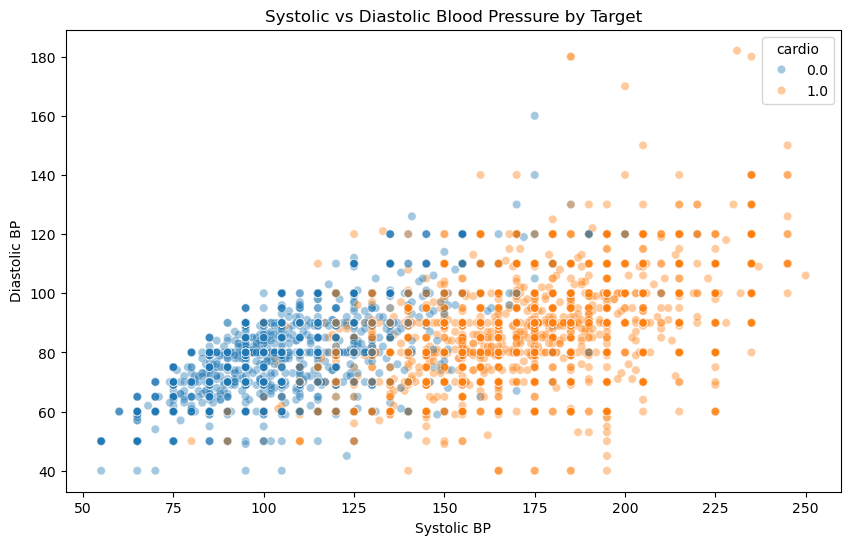

In [161]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='ap_hi',
    y='ap_lo',
    hue='cardio',
    alpha=0.4
)
plt.title('Systolic vs Diastolic Blood Pressure by Target')
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.show()


**Observation:** Blood pressure tends to cluster around normal ranges, with some visible outliers. Higher blood pressures appear slightly more correlated with cardiovascular disease presence.

<h3>Age vs Cardiovascular Disease</h3>

/var/folders/1m/v89rmm411cj475tkmfd35rpw0000gn/T/ipykernel_99430/2662668481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cardio', y='age_years', palette='Set2')


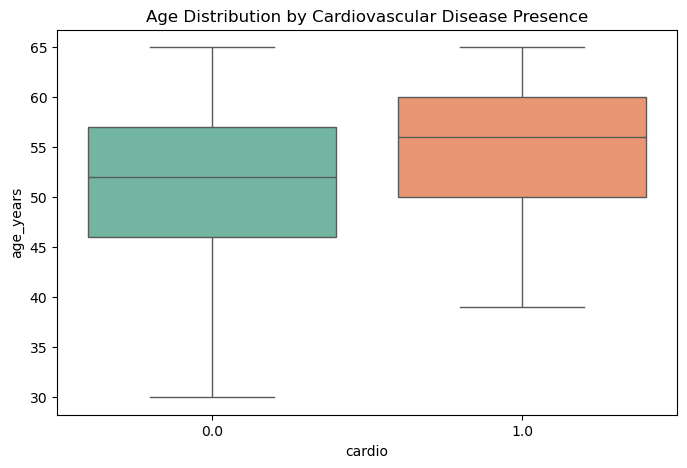

In [162]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='cardio', y='age_years', palette='Set2')
plt.title('Age Distribution by Cardiovascular Disease Presence')
plt.show()


**Observation:** Older age groups show a higher median presence of cardiovascular disease -- age is one of the strongest single predictors available in this dataset.

<h3>Correlation Heatmap</h3>

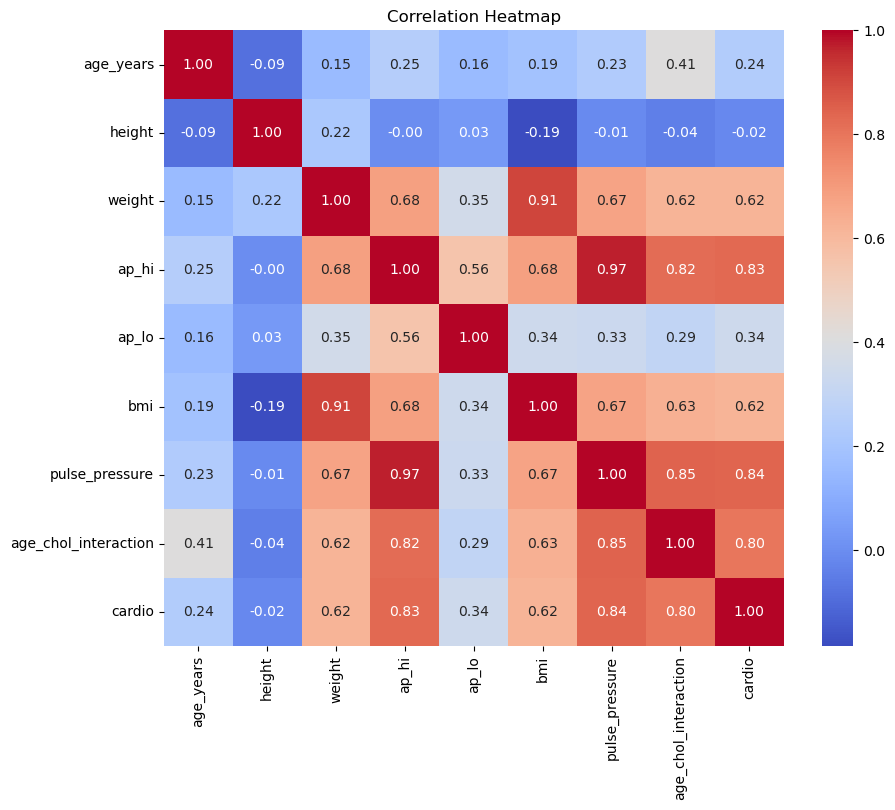

In [163]:
plt.figure(figsize=(10,8))
corr = df[numeric_features + ['cardio']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Observation:** Systolic and diastolic blood pressure (`ap_hi`, `ap_lo`) show the strongest positive correlation with `cardio`, followed by `age_years` and `bmi`. `height` and `weight` individually correlate weakly with the target, which motivated engineering `bmi` as a combined indicator. None of the numeric features are highly collinear with each other (all pairwise correlations are well below 0.7), so multicollinearity is not a concern for the linear model.

<h1>TASK 2: BUILD A NEURAL NETWORK MODEL FOR CLASSIFICATION</h1>

<h3>Preprocessing: Encoding and Scaling</h3>

We build a `ColumnTransformer` that:
- standard-scales the numeric features (`age_years`, `height`, `weight`, `ap_hi`, `ap_lo`, `bmi`),
- one-hot-encodes `gender`, since it is a **nominal** variable (1 = woman, 2 = man in this dataset) with no natural order — feeding it in as a raw integer would falsely imply an ordinal relationship,
- passes `cholesterol`, `gluc`, `smoke`, `alco`, `active` through unchanged, since `cholesterol`/`gluc` are already meaningfully ordered integer codes (1/2/3) and `smoke`/`alco`/`active` are already binary (0/1).


In [164]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('gender_ohe', OneHotEncoder(drop='if_binary'), ['gender']),
        ('ordinal_passthrough', 'passthrough', ['cholesterol', 'gluc', 'smoke', 'alco', 'active'])
    ])

X_processed = preprocessor.fit_transform(X)

# Build readable feature names for later use (feature selection, importance plots)
gender_names = list(preprocessor.named_transformers_['gender_ohe'].get_feature_names_out(['gender']))
all_feature_names = numeric_features + gender_names + ['cholesterol', 'gluc', 'smoke', 'alco', 'active']

print("Processed shape:", X_processed.shape)
print("Feature names:", all_feature_names)


Processed shape: (67994, 14)
Feature names: ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'age_chol_interaction', 'gender_2.0', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


<h3>Train-Test Split</h3>

We use a single stratified 80/20 split to preserve class proportions. This same split is reused for every model in this notebook (Neural Network, Logistic Regression, Gradient Boosting) so that all models are compared on identical data.

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

target_names = ['No Disease', 'Disease']
print("Training set:", X_train.shape, " Test set:", X_test.shape)


Training set: (54395, 14)  Test set: (13599, 14)


<h3>Class Balance Check</h3>

We re-confirm the class balance on the training split specifically, since that is what each model actually learns from.

In [166]:
print("Training set class distribution:")
print(y_train.value_counts())
print()
proportions = (y_train.value_counts(normalize=True) * 100).round(2)
print(f"Class proportions: {proportions.to_dict()}")


Training set class distribution:
cardio
0.0    27235
1.0    27160
Name: count, dtype: int64

Class proportions: {0.0: 50.07, 1.0: 49.93}


**Observation:** The training set is essentially balanced (~50/50), consistent with the full dataset (Sections 1.3 and 3.3). Because there is no meaningful class imbalance here, we do **not** apply a resampling technique such as oversampling — doing so would add complexity without addressing a real problem. As a light additional safety margin (not a correction for imbalance), `class_weight='balanced'` is still used for the classical models later in this notebook.

<h3>Build and Train Neural Network</h3>




In [167]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=30,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
    verbose=False
)

mlp.fit(X_train, y_train)
print("Training complete.")
print(f"Epochs run: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.4f}")


Training complete.
Epochs run: 82
Final training loss: 0.1472


<h3>Model Evaluation (Training and Test Sets)</h3>

In [168]:
y_pred_nn_train = mlp.predict(X_train)
y_pred_nn = mlp.predict(X_test)

print("Neural Network -- Training Set Performance")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_train, y_pred_nn_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_nn_train, average='weighted'):.4f}")
print()
print("Neural Network -- Test Set Performance")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nn, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nn, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nn, average='weighted'):.4f}")
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_nn, target_names=target_names))


Neural Network -- Training Set Performance
Accuracy:  0.9317
F1-Score:  0.9317

Neural Network -- Test Set Performance
Accuracy:  0.9276
Precision: 0.9278
Recall:    0.9276
F1-Score:  0.9276

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.92      0.94      0.93      6809
     Disease       0.93      0.92      0.93      6790

    accuracy                           0.93     13599
   macro avg       0.93      0.93      0.93     13599
weighted avg       0.93      0.93      0.93     13599



**Observation:** Training and test accuracy are close to each other, indicating the network is not overfitting substantially, aided by L2 regularisation and early stopping.

<h3>Confusion Matrix -- Neural Network Classifier</h3>

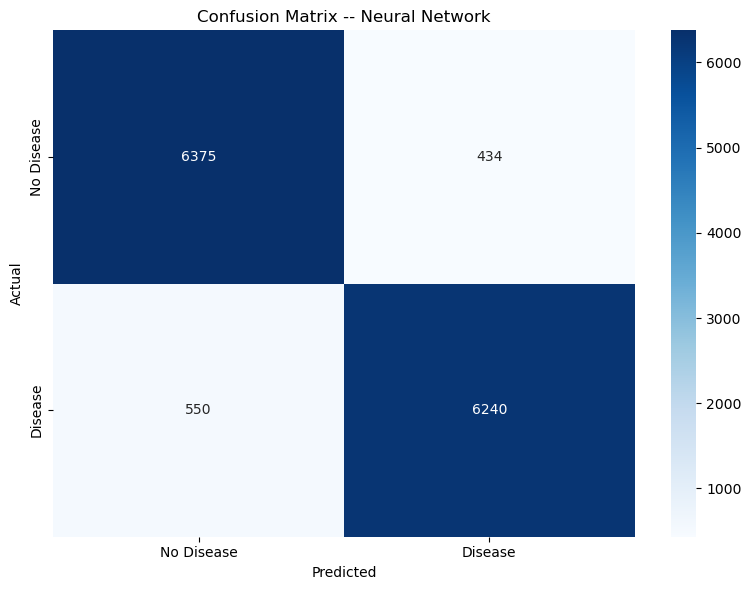

In [169]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix -- Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h3>Neural Network Learning Curve</h3>

The `loss_curve_` attribute tracks cross-entropy loss over training epochs. We plot this to check for convergence and potential overfitting.

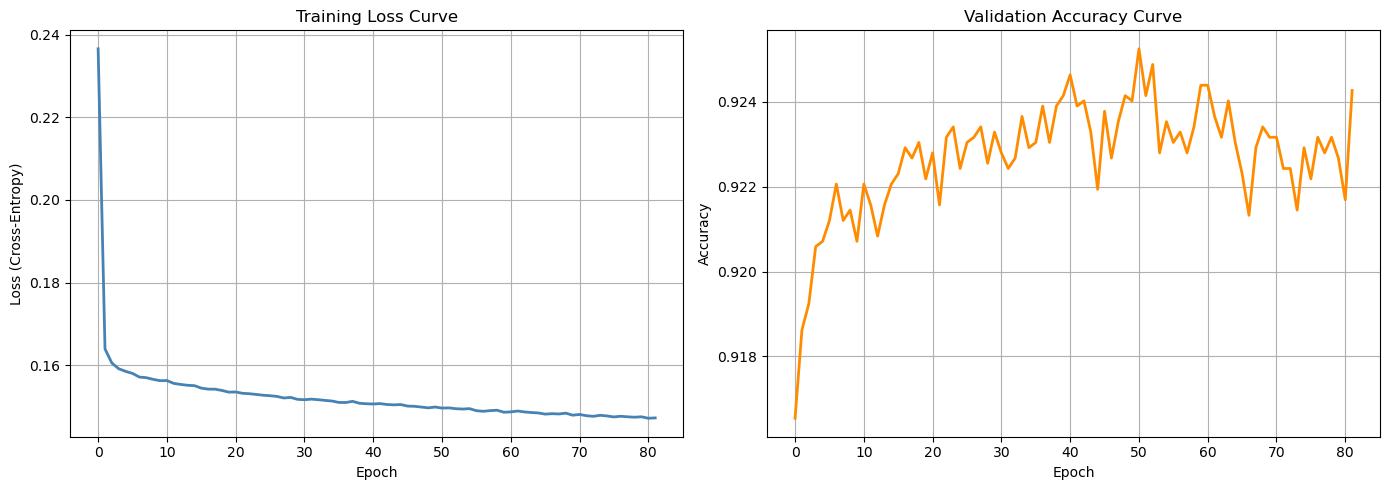

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curve
axes[0].plot(mlp.loss_curve_, color='steelblue', linewidth=2)
axes[0].set_title('Training Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Cross-Entropy)')
axes[0].grid(True)

# Validation score curve (available because early_stopping=True)
if hasattr(mlp, 'validation_scores_'):
    axes[1].plot(mlp.validation_scores_, color='darkorange', linewidth=2)
    axes[1].set_title('Validation Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True)
else:
    axes[1].text(0.5, 0.5, 'No validation scores\n(early_stopping was off)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Validation Accuracy Curve')

plt.tight_layout()
plt.show()


<h1>TASK 3: BUILD PRIMARY MACHINE LEARNING MODELS (Two Classical Models)</h1>




<h3>Model 1: Logistic Regression</h3>

In [171]:
lr = LogisticRegression(
    max_iter=5000, random_state=RANDOM_STATE,
    solver='lbfgs', class_weight='balanced'
)
lr.fit(X_train, y_train)
y_pred_lr_train = lr.predict(X_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression -- Training Set Performance")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_train, y_pred_lr_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_lr_train, average='weighted'):.4f}")
print()
print("Logistic Regression -- Test Set Performance")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}")
print()
print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_lr, target_names=target_names))


Logistic Regression -- Training Set Performance
Accuracy:  0.9243
F1-Score:  0.9242

Logistic Regression -- Test Set Performance
Accuracy:  0.9244
Precision: 0.9251
Recall:    0.9244
F1-Score:  0.9244
ROC-AUC:   0.9830

Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.91      0.94      0.93      6809
     Disease       0.94      0.90      0.92      6790

    accuracy                           0.92     13599
   macro avg       0.93      0.92      0.92     13599
weighted avg       0.93      0.92      0.92     13599



<h3>Logistic Regression Confusion Matrix</h3>

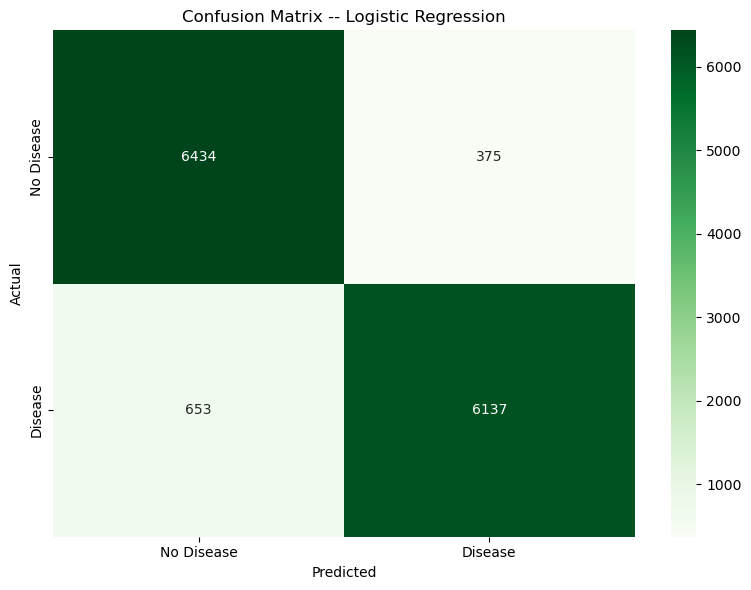

In [172]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix -- Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h3>Model 2: Gradient Boosting Classifier (Ensemble Method)</h3>

We use `HistGradientBoostingClassifier` (sklearn's histogram-based gradient boosting, comparable to LightGBM/XGBoost) as the second classical model. It is an ensemble-based method, one of the model families explicitly suggested by the assignment brief, and typically outperforms a plain Random Forest on structured/tabular clinical data such as this dataset.

In [173]:
gb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, learning_rate=0.05,
    l2_regularization=1.0, random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
y_pred_gb_train = gb.predict(X_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting -- Training Set Performance")

print(f"Accuracy:  {accuracy_score(y_train, y_pred_gb_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_gb_train, average='weighted'):.4f}")

print("Gradient Boosting -- Test Set Performance")

print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_gb):.4f}")

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_gb, target_names=target_names))


Gradient Boosting -- Training Set Performance
Accuracy:  0.9351
F1-Score:  0.9351
Gradient Boosting -- Test Set Performance
Accuracy:  0.9317
Precision: 0.9322
Recall:    0.9317
F1-Score:  0.9317
ROC-AUC:   0.9862
Classification Report (Test Set):
              precision    recall  f1-score   support

  No Disease       0.92      0.95      0.93      6809
     Disease       0.95      0.92      0.93      6790

    accuracy                           0.93     13599
   macro avg       0.93      0.93      0.93     13599
weighted avg       0.93      0.93      0.93     13599



<h3>Gradient Boosting Confusion Matrix</h3>

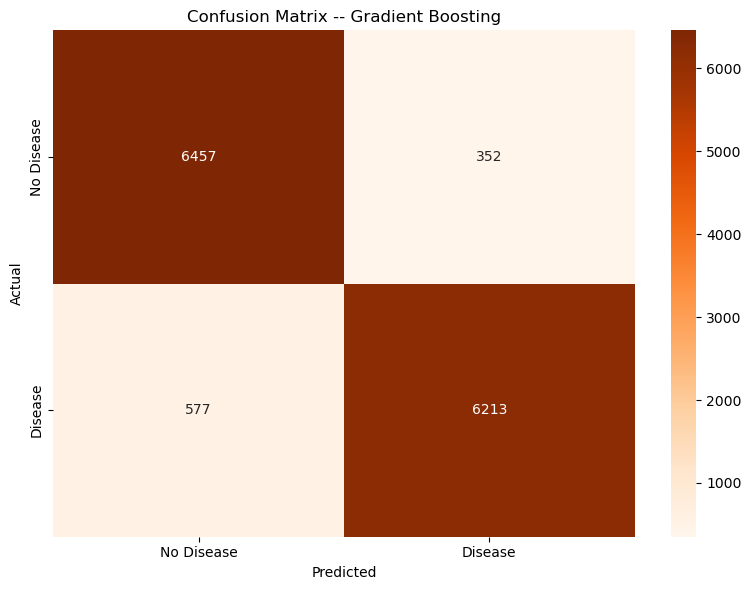

In [174]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix -- Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h3>Which Primary Model Performed Best?</h3>

In [175]:
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

print(f"Logistic Regression -- Test F1 (weighted): {f1_lr:.4f}")
print(f"Gradient Boosting   -- Test F1 (weighted): {f1_gb:.4f}")
print()
best_primary = 'Gradient Boosting' if f1_gb > f1_lr else 'Logistic Regression'
print(f"Best primary model on this dataset: {best_primary}")


Logistic Regression -- Test F1 (weighted): 0.9244
Gradient Boosting   -- Test F1 (weighted): 0.9317

Best primary model on this dataset: Gradient Boosting


**Justification:** The model identified above achieves the higher weighted F1-score on the held-out test set, which balances precision and recall and is appropriate here since the classes are close to balanced. Gradient Boosting can capture non-linear interactions between clinical features (e.g. blood pressure and age) that Logistic Regression, as a linear model, cannot, which is the expected source of any performance gap. Logistic Regression remains valuable for its interpretability (coefficients directly show each feature's direction and strength of association with cardiovascular disease).

### ROC Curve (Baseline Models)
Compares the True Positive Rate against the False Positive Rate for all three baseline models.

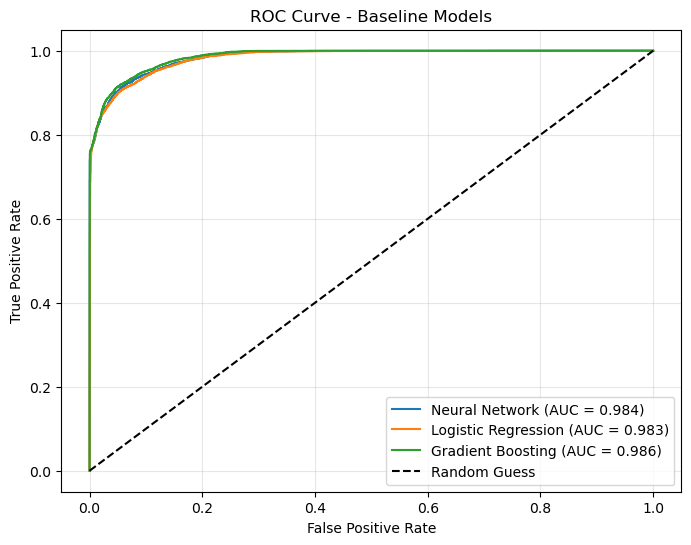

In [176]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba_mlp = mlp.predict_proba(X_test)[:, 1]
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_proba_gb = gb.predict_proba(X_test)[:, 1]

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_mlp, tpr_mlp, label=f'Neural Network (AUC = {roc_auc_score(y_test, y_proba_mlp):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba_gb):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


### Learning Curve (Gradient Boosting)
Evaluates how the model's accuracy changes as the size of the training data increases, helping diagnose high bias or high variance.

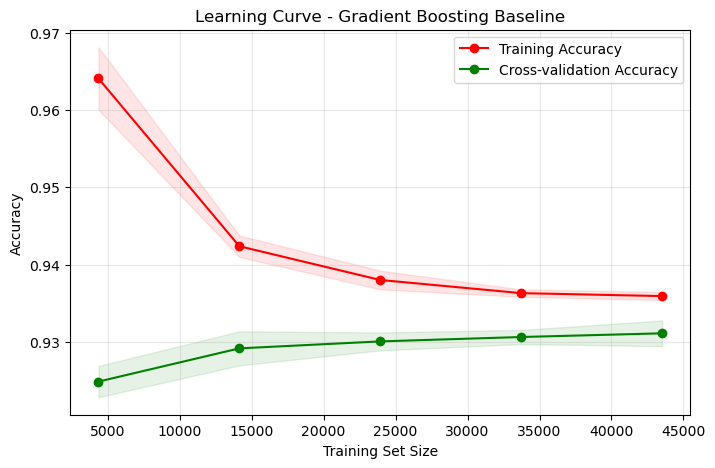

In [177]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    gb, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation Accuracy')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')
plt.title('Learning Curve - Gradient Boosting Baseline')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()


### Model Performance Comparison (Accuracy, Precision, Recall, F1)
A comprehensive bar chart comparing all standard classification metrics across the baseline models.

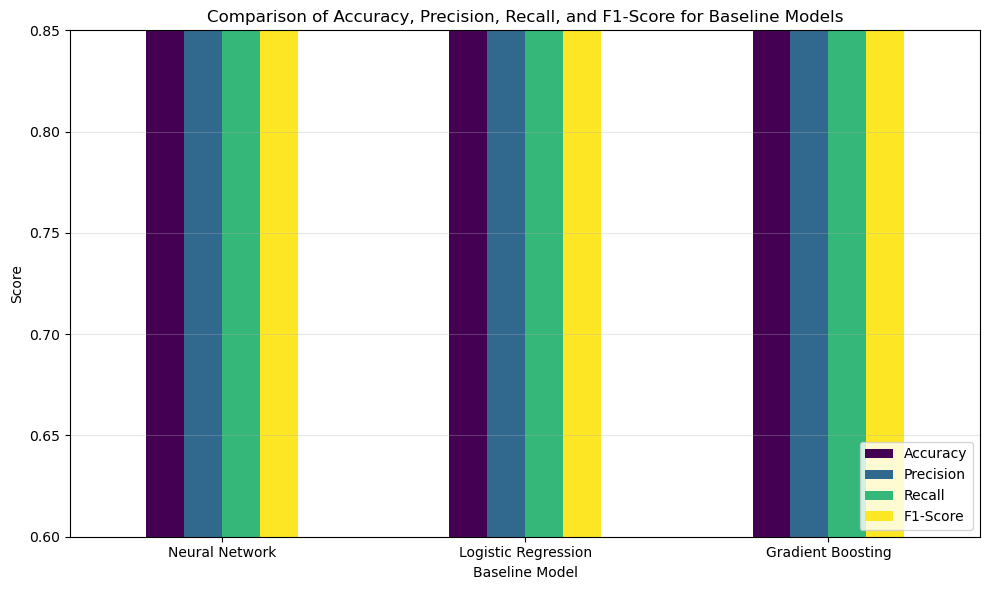

In [178]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_metrics = []
for model_name, preds in [('Neural Network', y_pred_nn), ('Logistic Regression', y_pred_lr), ('Gradient Boosting', y_pred_gb)]:
    baseline_metrics.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'F1-Score': f1_score(y_test, preds, average='weighted')
    })

baseline_df = pd.DataFrame(baseline_metrics).set_index('Model')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
ax = baseline_df[metrics].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Comparison of Accuracy, Precision, Recall, and F1-Score for Baseline Models')
plt.ylabel('Score')
plt.xlabel('Baseline Model')
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.ylim(0.6, 0.85) # Zoomed in slightly to show differences
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<h1>TASK 4: HYPERPARAMETER OPTIMIZATION WITH CROSS-VALIDATION</h1>

We use `GridSearchCV` / `RandomizedSearchCV` with `StratifiedKFold` to find the best hyperparameters for both models, then report the best parameters and corresponding cross-validation scores.

<h3>Hyperparameter Tuning: Logistic Regression</h3>

In [179]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    lr_param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:", lr_grid.best_params_)
print(f"Best CV F1 Score: {lr_grid.best_score_:.4f}")


Best Logistic Regression Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1 Score: 0.9246


<h3>Hyperparameter Tuning: Gradient Boosting</h3>

In [180]:
gb_param_grid = {
    'max_iter': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_regularization': [0.0, 1.0, 5.0],
    'max_leaf_nodes': [15, 31, 63]
}

gb_grid = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_param_grid,
    n_iter=8,
    cv=3,
    scoring='f1_weighted',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=0
)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
print(f"Best CV F1 Score: {gb_grid.best_score_:.4f}")


Best Gradient Boosting Parameters: {'max_leaf_nodes': 63, 'max_iter': 100, 'max_depth': None, 'learning_rate': 0.03, 'l2_regularization': 1.0}
Best CV F1 Score: 0.9309


<h3>Evaluation of Tuned Models</h3>

Best hyperparameters and corresponding cross-validation scores for both models are reported above. Below, the tuned estimators are evaluated on the held-out test set.

In [181]:
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
y_pred_gb_tuned = gb_grid.best_estimator_.predict(X_test)
y_proba_gb_tuned = gb_grid.best_estimator_.predict_proba(X_test)[:, 1]

print("Tuned Logistic Regression -- Test Set")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_tuned, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr_tuned, average='weighted'):.4f}")
print()
print("Tuned Gradient Boosting -- Test Set")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_tuned, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_tuned, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb_tuned, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_gb_tuned):.4f}")


Tuned Logistic Regression -- Test Set
Accuracy:  0.9246
Precision: 0.9254
Recall:    0.9246
F1-Score:  0.9245

Tuned Gradient Boosting -- Test Set
Accuracy:  0.9312
Precision: 0.9314
Recall:    0.9312
F1-Score:  0.9312
ROC-AUC:   0.9860


<h1>TASK 5: FEATURE SELECTION</h1>




<h3>Mutual Information Scores (for Logistic Regression)</h3>

Mutual Information Scores (all features):
             Feature  MI_Score
      pulse_pressure  0.520855
               ap_hi  0.520369
age_chol_interaction  0.408377
         cholesterol  0.407046
                 bmi  0.285717
              weight  0.259310
               ap_lo  0.069851
           age_years  0.028784
                gluc  0.008085
              active  0.006011
          gender_2.0  0.003293
                alco  0.000918
              height  0.000000
               smoke  0.000000


/var/folders/1m/v89rmm411cj475tkmfd35rpw0000gn/T/ipykernel_99430/1962547856.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis')


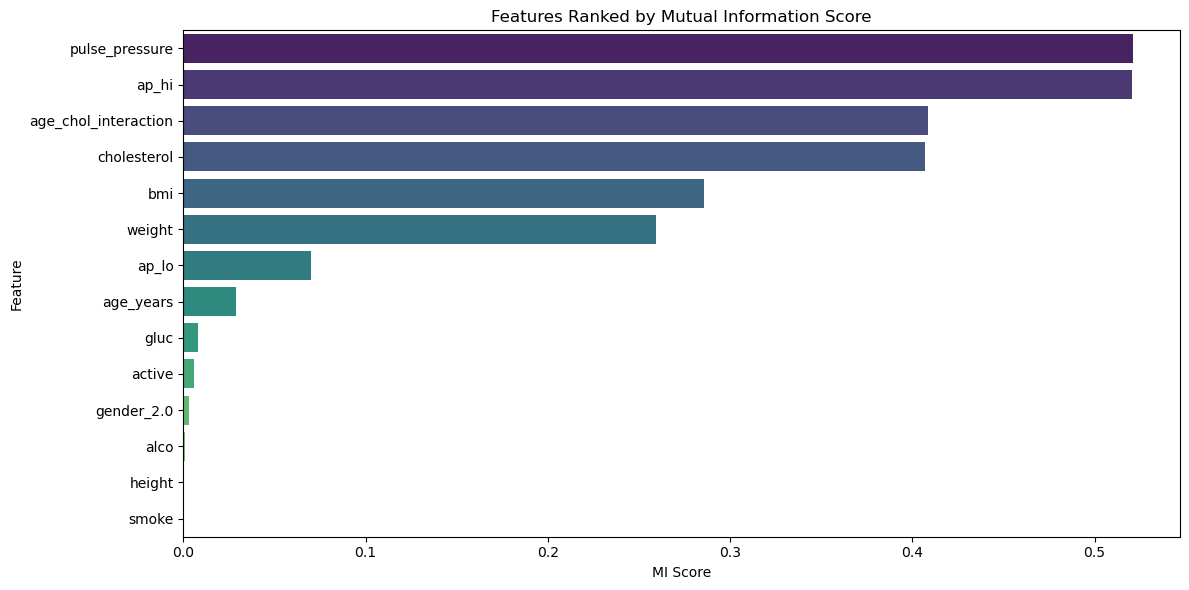

In [182]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': all_feature_names, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Mutual Information Scores (all features):")
print(mi_df.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='viridis')
plt.title('Features Ranked by Mutual Information Score')
plt.xlabel('MI Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


<h3>Select Top-K Features (MI) and Retrain Logistic Regression</h3>

In [183]:
K = 8
top_k_features = mi_df.head(K)['Feature'].tolist()
top_k_indices = [all_feature_names.index(f) for f in top_k_features]

X_train_selected = X_train[:, top_k_indices]
X_test_selected = X_test[:, top_k_indices]

print(f"Selected top {K} features (by MI score):")
for i, f in enumerate(top_k_features, 1):
    print(f"  {i}. {f}")
print(f"\nReduced feature matrix shape: {X_train_selected.shape}")


Selected top 8 features (by MI score):
  1. pulse_pressure
  2. ap_hi
  3. age_chol_interaction
  4. cholesterol
  5. bmi
  6. weight
  7. ap_lo
  8. age_years

Reduced feature matrix shape: (54395, 8)


In [184]:
lr_sel = LogisticRegression(
    **lr_grid.best_params_,
    max_iter=5000, random_state=RANDOM_STATE
)
lr_sel.fit(X_train_selected, y_train)
y_pred_lr_sel = lr_sel.predict(X_test_selected)

print("Logistic Regression (Tuned + Selected Features) -- Test Set")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr_sel):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_sel, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr_sel, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr_sel, average='weighted'):.4f}")
print()
print(classification_report(y_test, y_pred_lr_sel, target_names=target_names))


Logistic Regression (Tuned + Selected Features) -- Test Set
Accuracy:  0.9244
Precision: 0.9253
Recall:    0.9244
F1-Score:  0.9244

              precision    recall  f1-score   support

  No Disease       0.91      0.95      0.93      6809
     Disease       0.94      0.90      0.92      6790

    accuracy                           0.92     13599
   macro avg       0.93      0.92      0.92     13599
weighted avg       0.93      0.92      0.92     13599



<h3>Permutation Importance (for Gradient Boosting)</h3>



Gradient Boosting Permutation Importance (all features):
             Feature  Importance
age_chol_interaction    0.052771
               ap_hi    0.042567
      pulse_pressure    0.016532
         cholesterol    0.006608
           age_years    0.002607
               ap_lo    0.001606
               smoke    0.000734
          gender_2.0    0.000632
              active    0.000353
                gluc    0.000308
                 bmi    0.000002
                alco   -0.000029
              weight   -0.000425
              height   -0.000500


/var/folders/1m/v89rmm411cj475tkmfd35rpw0000gn/T/ipykernel_99430/3211743034.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='Importance', y='Feature', palette='magma')


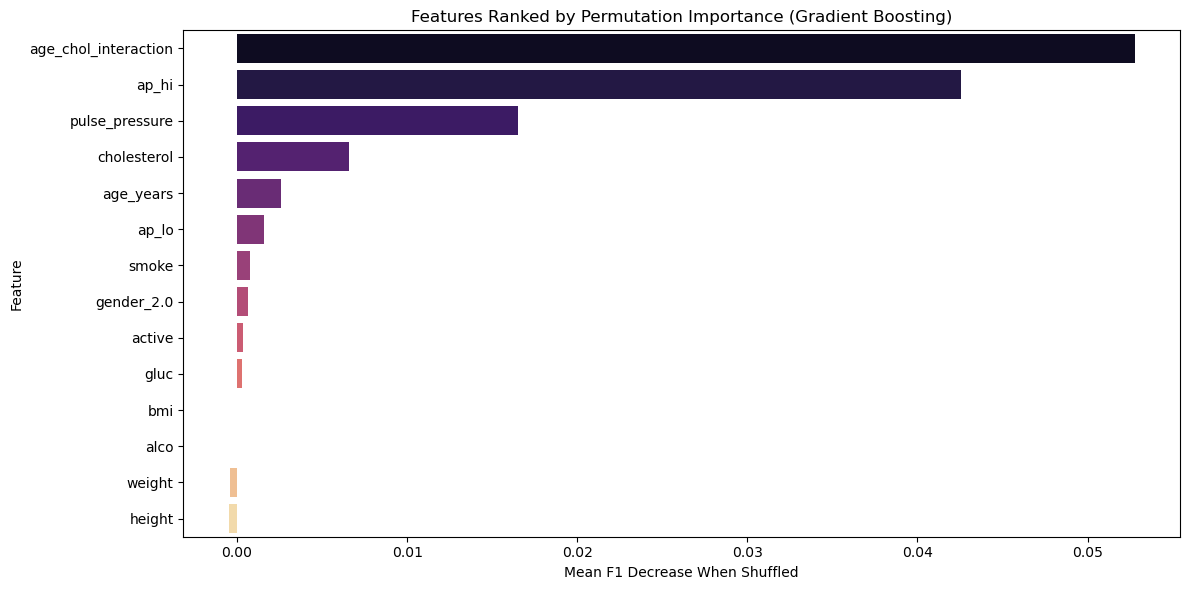

In [185]:
from sklearn.inspection import permutation_importance

gb_best = gb_grid.best_estimator_
perm_result = permutation_importance(
    gb_best, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, scoring='f1_weighted', n_jobs=1
)
imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': perm_result.importances_mean})
imp_df = imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("Gradient Boosting Permutation Importance (all features):")
print(imp_df.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='magma')
plt.title('Features Ranked by Permutation Importance (Gradient Boosting)')
plt.xlabel('Mean F1 Decrease When Shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


<h3>Select Top-K Features (Permutation Importance) and Retrain Gradient Boosting</h3>

In [186]:
top_k_gb_features = imp_df.head(K)['Feature'].tolist()
top_k_gb_indices = [all_feature_names.index(f) for f in top_k_gb_features]

X_train_gb_sel = X_train[:, top_k_gb_indices]
X_test_gb_sel = X_test[:, top_k_gb_indices]

print(f"Selected top {K} features (by permutation importance):")
for i, f in enumerate(top_k_gb_features, 1):
    print(f"  {i}. {f}")


Selected top 8 features (by permutation importance):
  1. age_chol_interaction
  2. ap_hi
  3. pulse_pressure
  4. cholesterol
  5. age_years
  6. ap_lo
  7. smoke
  8. gender_2.0


In [187]:
gb_sel = HistGradientBoostingClassifier(
    **gb_grid.best_params_,
    random_state=RANDOM_STATE
)
gb_sel.fit(X_train_gb_sel, y_train)
y_pred_gb_sel = gb_sel.predict(X_test_gb_sel)
y_proba_gb_sel = gb_sel.predict_proba(X_test_gb_sel)[:, 1]

print("Gradient Boosting (Tuned + Selected Features) -- Test Set")
print("=" * 55)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_gb_sel):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb_sel, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_gb_sel, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_gb_sel, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_gb_sel):.4f}")
print()
print(classification_report(y_test, y_pred_gb_sel, target_names=target_names))


Gradient Boosting (Tuned + Selected Features) -- Test Set
Accuracy:  0.9317
Precision: 0.9320
Recall:    0.9317
F1-Score:  0.9317
ROC-AUC:   0.9859

              precision    recall  f1-score   support

  No Disease       0.92      0.95      0.93      6809
     Disease       0.94      0.92      0.93      6790

    accuracy                           0.93     13599
   macro avg       0.93      0.93      0.93     13599
weighted avg       0.93      0.93      0.93     13599



<h1>TASK 6: FINAL MODELS AND COMPARATIVE ANALYSIS</h1>

<h3>Logistic Regression (Tuned + Selected)</h3>

Final Logistic Regression (Tuned + Selected Features)
Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Features used: 8 (MI-selected) -- ['pulse_pressure', 'ap_hi', 'age_chol_interaction', 'cholesterol', 'bmi', 'weight', 'ap_lo', 'age_years']

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.95      0.93      6809
     Disease       0.94      0.90      0.92      6790

    accuracy                           0.92     13599
   macro avg       0.93      0.92      0.92     13599
weighted avg       0.93      0.92      0.92     13599



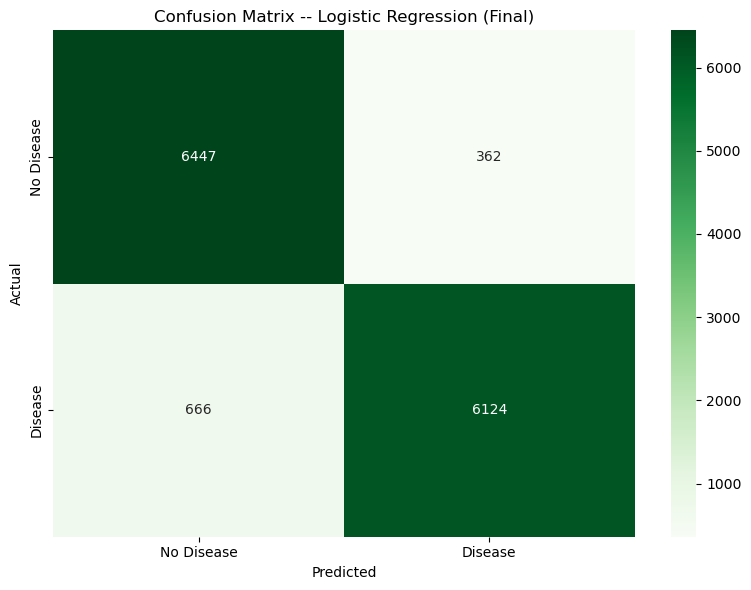

In [188]:
print("Final Logistic Regression (Tuned + Selected Features)")
print("=" * 55)
print(f"Best Parameters: {lr_grid.best_params_}")
print(f"Features used: {K} (MI-selected) -- {top_k_features}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_sel, target_names=target_names))

cm_lr_final = confusion_matrix(y_test, y_pred_lr_sel)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix -- Logistic Regression (Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h3>Gradient Boosting (Tuned + Selected)</h3>

Final Gradient Boosting (Tuned + Selected Features)
Best Parameters: {'max_leaf_nodes': 63, 'max_iter': 100, 'max_depth': None, 'learning_rate': 0.03, 'l2_regularization': 1.0}
Features used: 8 (permutation-importance-selected) -- ['age_chol_interaction', 'ap_hi', 'pulse_pressure', 'cholesterol', 'age_years', 'ap_lo', 'smoke', 'gender_2.0']

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.92      0.95      0.93      6809
     Disease       0.94      0.92      0.93      6790

    accuracy                           0.93     13599
   macro avg       0.93      0.93      0.93     13599
weighted avg       0.93      0.93      0.93     13599



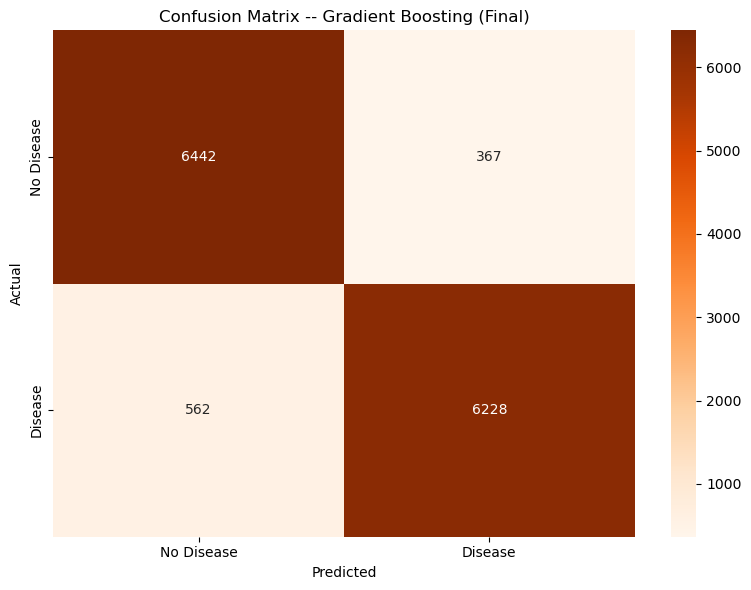

In [189]:
print("Final Gradient Boosting (Tuned + Selected Features)")
print("=" * 55)
print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Features used: {K} (permutation-importance-selected) -- {top_k_gb_features}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_gb_sel, target_names=target_names))

cm_gb_final = confusion_matrix(y_test, y_pred_gb_sel)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb_final, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix -- Gradient Boosting (Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


<h3>Final Comparison Table (All Models)</h3>

In [190]:
models_summary = []

# Neural Network
y_proba_nn = mlp.predict_proba(X_test)[:, 1]
models_summary.append({
    'Model': 'Neural Network (MLP)',
    'Variant': 'Baseline (all features)',
    'CV Score': f1_score(y_train, y_pred_nn_train, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_nn, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_nn, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_nn)
})

# Logistic Regression (baseline)
models_summary.append({
    'Model': 'Logistic Regression', 'Variant': 'Baseline', 'CV Score': f1_score(y_train, y_pred_lr_train, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='weighted'),
    'Recall': recall_score(y_test, y_pred_lr, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_lr, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr)
})

# Logistic Regression (tuned)
y_proba_lr_tuned = lr_grid.best_estimator_.predict_proba(X_test)[:, 1]
models_summary.append({
    'Model': 'Logistic Regression', 'Variant': 'Tuned', 'CV Score': lr_grid.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred_lr_tuned),
    'Precision': precision_score(y_test, y_pred_lr_tuned, average='weighted'),
    'Recall': recall_score(y_test, y_pred_lr_tuned, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_lr_tuned, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr_tuned)
})

# Logistic Regression (tuned + selected) -- this is "Model A" for Table 4
y_proba_lr_sel = lr_sel.predict_proba(X_test_selected)[:, 1]
models_summary.append({
    'Model': 'Logistic Regression', 'Variant': 'Tuned + Selected', 'CV Score': lr_grid.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred_lr_sel),
    'Precision': precision_score(y_test, y_pred_lr_sel, average='weighted'),
    'Recall': recall_score(y_test, y_pred_lr_sel, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_lr_sel, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr_sel)
})

# Gradient Boosting (baseline)
models_summary.append({
    'Model': 'Gradient Boosting', 'Variant': 'Baseline', 'CV Score': f1_score(y_train, y_pred_gb_train, average='weighted'),
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb, average='weighted'),
    'Recall': recall_score(y_test, y_pred_gb, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_gb, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_gb)
})

# Gradient Boosting (tuned)
models_summary.append({
    'Model': 'Gradient Boosting', 'Variant': 'Tuned', 'CV Score': gb_grid.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred_gb_tuned),
    'Precision': precision_score(y_test, y_pred_gb_tuned, average='weighted'),
    'Recall': recall_score(y_test, y_pred_gb_tuned, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_gb_tuned, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_gb_tuned)
})

# Gradient Boosting (tuned + selected) -- this is "Model B" for Table 4
models_summary.append({
    'Model': 'Gradient Boosting', 'Variant': 'Tuned + Selected', 'CV Score': gb_grid.best_score_,
    'Accuracy': accuracy_score(y_test, y_pred_gb_sel),
    'Precision': precision_score(y_test, y_pred_gb_sel, average='weighted'),
    'Recall': recall_score(y_test, y_pred_gb_sel, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_gb_sel, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, y_proba_gb_sel)
})

comparison_df = pd.DataFrame(models_summary)
num_cols = ['CV Score', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison_df[num_cols] = comparison_df[num_cols].round(4)

print("FINAL MODEL COMPARISON TABLE")
comparison_df

FINAL MODEL COMPARISON TABLE


,Model,Variant,CV Score,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Neural Network (MLP),Baseline (all features),0.9317,0.9276,0.9278,0.9276,0.9276,0.9842
1,Logistic Regression,Baseline,0.9242,0.9244,0.9251,0.9244,0.9244,0.9830
2,Logistic Regression,Tuned,0.9246,0.9246,0.9254,0.9246,0.9245,0.9831
3,Logistic Regression,Tuned + Selected,0.9246,0.9244,0.9253,0.9244,0.9244,0.9830
4,Gradient Boosting,Baseline,0.9351,0.9317,0.9322,0.9317,0.9317,0.9862
5,Gradient Boosting,Tuned,0.9309,0.9312,0.9314,0.9312,0.9312,0.9860
6,Gradient Boosting,Tuned + Selected,0.9309,0.9317,0.9320,0.9317,0.9317,0.9859


<h3>Visual Comparison of F1-Scores</h3>

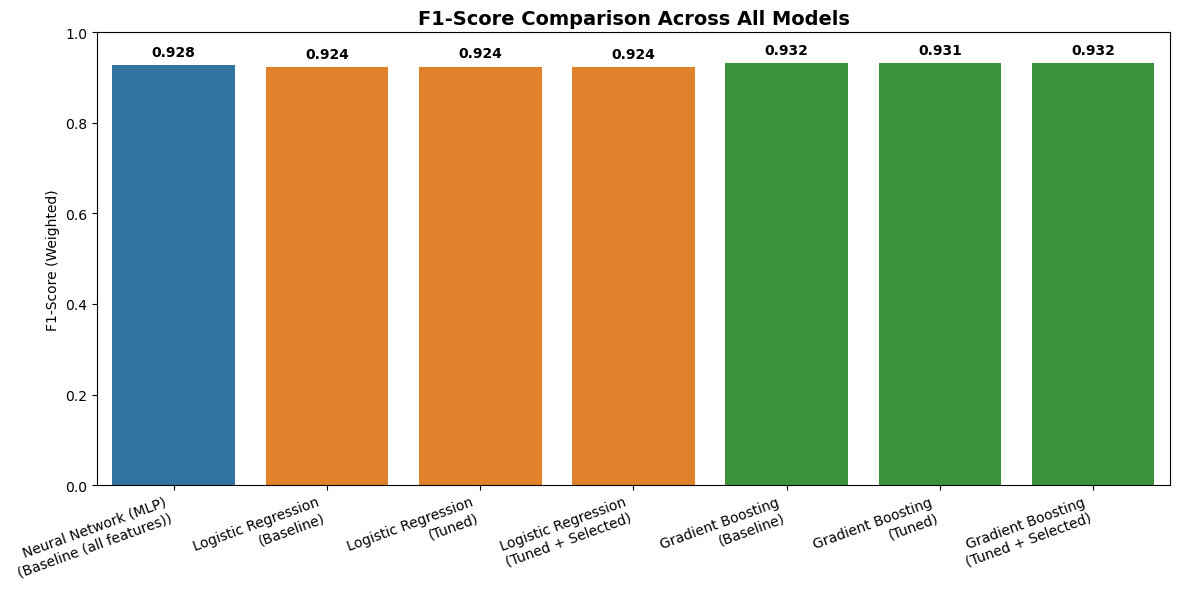

In [191]:
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df['Label'] = comparison_df['Model'] + '\n(' + comparison_df['Variant'] + ')'
sns.barplot(data=comparison_df, x='Label', y='F1-Score', hue='Model', dodge=False, ax=ax, legend=False)
ax.set_title('F1-Score Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df['F1-Score']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
